#RETO 3

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
jugadores = pd.read_excel('/content/drive/MyDrive/Analítica de Negocios/RETOS/3. In_App_Pur_Data.xlsx')
score = pd.read_excel('/content/drive/MyDrive/Analítica de Negocios/RETOS/3. In_App_Pur_Data.xlsx', sheet_name=1)

##Lmipieza de datos

In [4]:
jugadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Age         400 non-null    int64
 1   Sex         400 non-null    int64
 2   Income      400 non-null    int64
 3   Years       400 non-null    int64
 4   Hours       400 non-null    int64
 5   CreditCard  400 non-null    int64
 6   Facebook    400 non-null    int64
 7   Buy         400 non-null    int64
dtypes: int64(8)
memory usage: 25.1 KB


In [5]:
print(jugadores.groupby('Buy').size())

Buy
0    189
1    211
dtype: int64


In [6]:
#No hay datos vacíos entonces no es necesario usar dropna.
#Escojo las variables independientes del modelo
xd = jugadores[['Age','Sex','Income', 'Years', 'Hours', 'CreditCard', 'Facebook']]

In [7]:
#escojo la variable independiente del modelo
yd = jugadores['Buy'].dropna()

##Estadística descriptiva del modelo

In [8]:
import seaborn as sns


/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


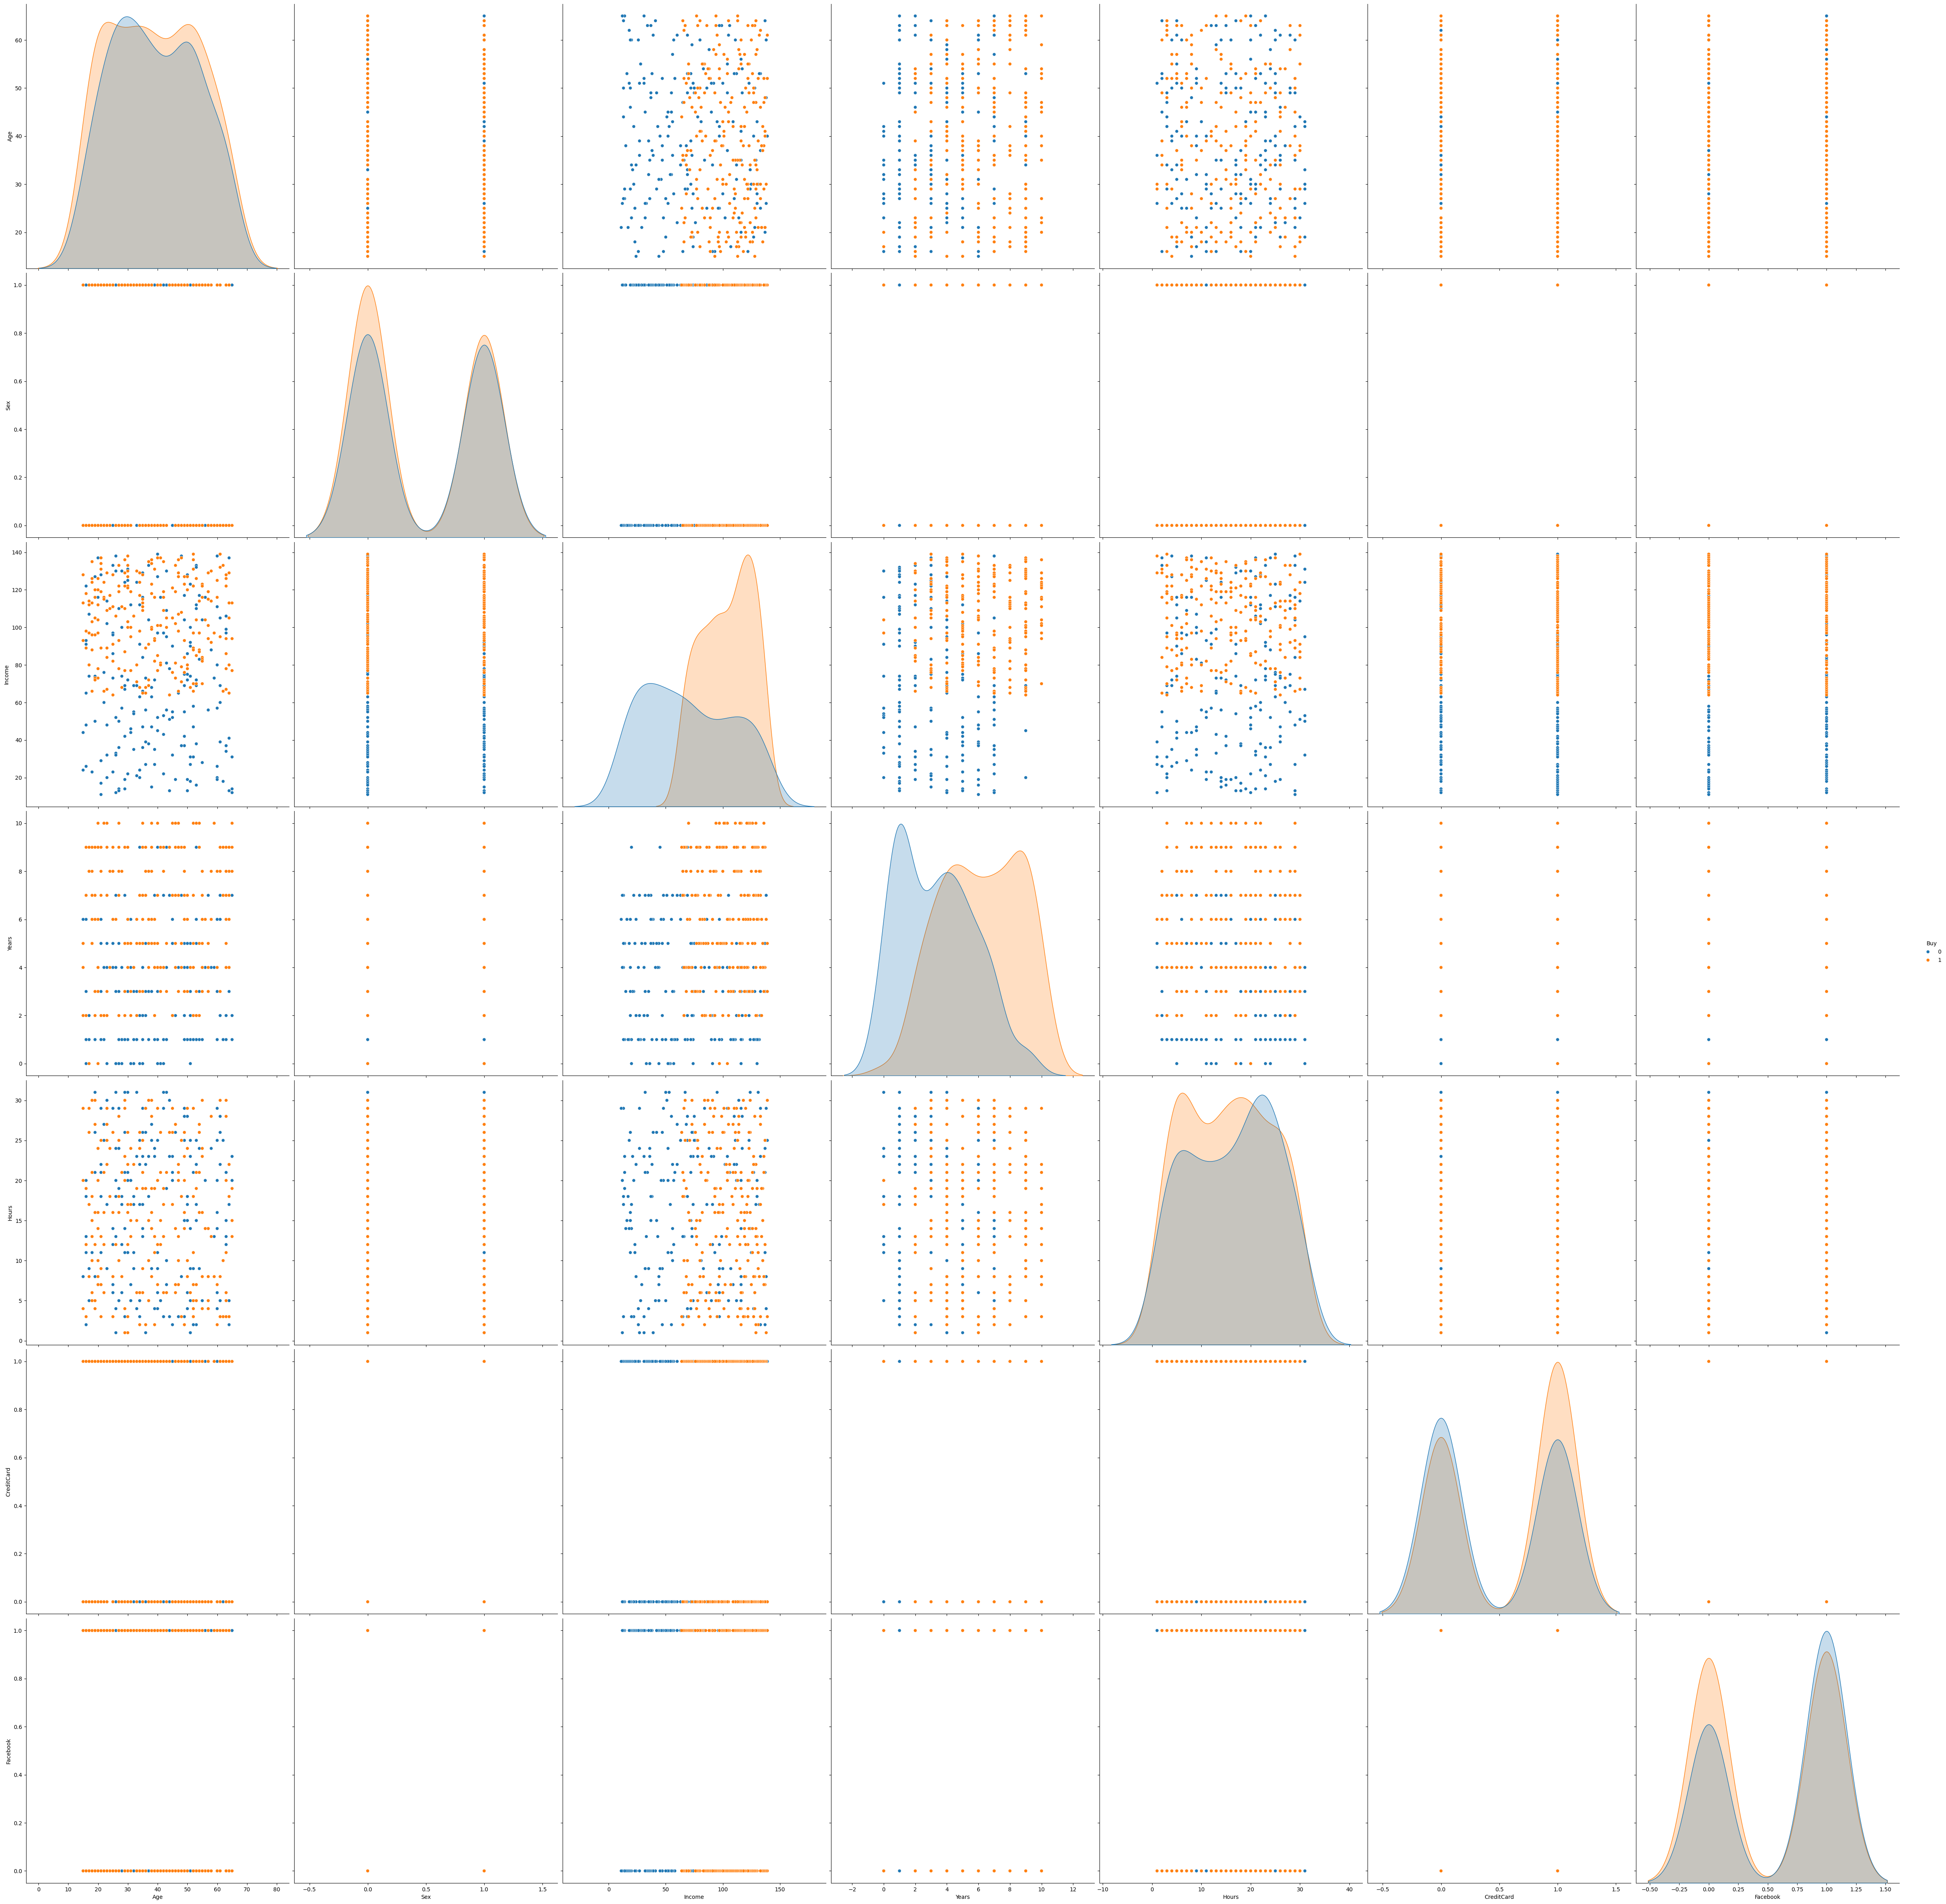

In [9]:
## Creo el pairplot
sns.pairplot(jugadores, hue='Buy', size=7, vars=['Age', 'Sex', 'Income', 'Years', 'Hours', 'CreditCard', 'Facebook'])


In [10]:
import numpy as np
#Creamos la matriz de correlación entre las variables
df = pd.DataFrame(np.column_stack((xd, yd)))
df.columns = ['Age', 'Sex', 'Income', 'Years', 'Hours', 'CreditCard', 'Facebook', 'Buy']
mCorr = df.corr()
mCorr

,Age,Sex,Income,Years,Hours,CreditCard,Facebook,Buy
Age,1.000000,-0.017348,-0.050346,0.051367,-0.050889,-0.024715,0.007843,-0.011375
Sex,-0.017348,1.000000,-0.041743,0.001476,-0.058782,-0.020544,0.053536,-0.041314
Income,-0.050346,-0.041743,1.000000,0.187323,0.006742,-0.008782,-0.018513,0.479961
Years,0.051367,0.001476,0.187323,1.000000,-0.044012,0.012473,-0.034714,0.497040
Hours,-0.050889,-0.058782,0.006742,-0.044012,1.000000,-0.113680,0.025439,-0.045375
CreditCard,-0.024715,-0.020544,-0.008782,0.012473,-0.113680,1.000000,-0.007541,0.116849
Facebook,0.007843,0.053536,-0.018513,-0.034714,0.025439,-0.007541,1.000000,-0.107197
Buy,-0.011375,-0.041314,0.479961,0.497040,-0.045375,0.116849,-0.107197,1.000000


<Axes: >

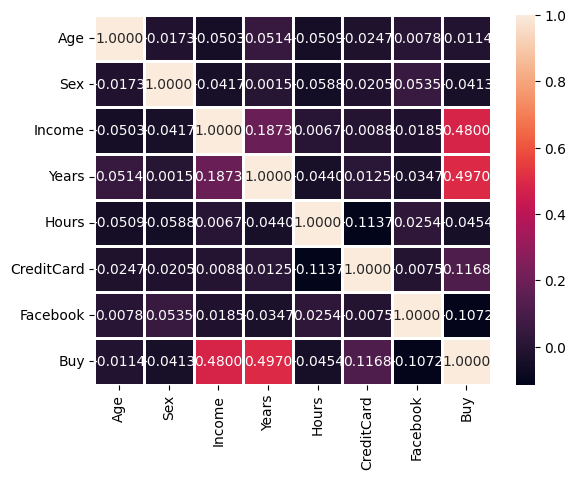

In [11]:
sns.heatmap(mCorr, linewidth= .8, annot=True, fmt='.4f')

##Implemento modelo KNN

In [12]:

from sklearn.neighbors import KNeighborsClassifier

In [13]:
### Creo la variable que aloja el modelo
knnModel = KNeighborsClassifier(n_neighbors=10)

In [14]:
xdarray = np.array(xd, dtype=float)
ydarray = np.array(yd, dtype=float)

In [15]:
#Entreno el modelo
knnModel.fit(xdarray, ydarray)


KNeighborsClassifier(n_neighbors=10)

In [16]:
#predigo los yd
ydPred= knnModel.predict(xdarray)
ydPred

array([1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0.,
       0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0.,
       1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
       0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

##Métricas de evaluación

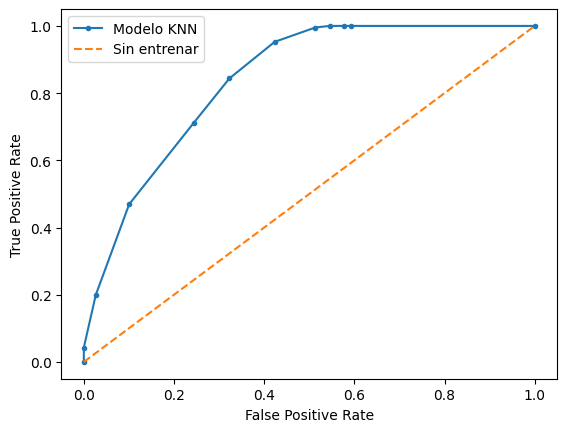

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve

lr_probs = knnModel.predict_proba(xdarray)
lr_probs = lr_probs[:, 1]

#Genero el clasificador sin entrenar
ns_probs = [0 for _ in range(len(xdarray))]

knn_fpr, knn_tpr, _ = roc_curve(ydarray, ydPred)
ns_fpr, ns_tpr, _ = roc_curve(ydarray, ns_probs)


lr_fpr, lr_tpr, _ = roc_curve(ydarray, lr_probs)
plt.plot(lr_fpr, lr_tpr, marker='.', label='Modelo KNN')
plt.plot(ns_fpr, ns_tpr, linestyle='--', label='Sin entrenar')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

#etiquetas de los ejes:


In [18]:
cm = confusion_matrix(yd, ydPred)
cm

array([[128,  61],
       [ 33, 178]])

In [19]:
#Matriz de confusión (cuadrantes)
vn = cm[0,0]; fp=cm[0,1]; fn=cm[1,0]; vp=cm[1,1]

In [20]:
#Exactitud
exactitud = (vn+vp)/cm.sum()
print(f'la exactitud (accuracy) del modelo es: {exactitud : .2%}')
#Tasa de error
error = 1 - exactitud
print(f'el error del modelo es: {error : .2%}')
#Precision
precision = vp/(fp+vp)
print(f'la precisión del modelo es: {precision : .2%}')
#Sensibilidad
sensibilidad = vp/(vp+fn)
print(f'la sensibilidad del modelo es: {sensibilidad : .2%}')
#Especificidad
Especificidad = vn/(vn+fp)
print(f'la especificidad del modelo es: {Especificidad : .2%}')

la exactitud (accuracy) del modelo es:  76.50%
el error del modelo es:  23.50%
la precisión del modelo es:  74.48%
la sensibilidad del modelo es:  84.36%
la especificidad del modelo es:  67.72%


In [21]:
roc_auc_score(yd, ydPred) #entre menor sea, es menos aleatorio el modelo.

0.7604252864916372

##Predicción de quienes usarían la app

In [22]:
xdgener = score[['Age', 'Sex', 'Income', 'Years', 'Hours', 'CreditCard', 'Facebook']]

In [23]:
#Hago la predicción
ydgener = knnModel.predict(xdgener)
ydgener

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


array([0., 1.])

##Predicción de un solo solicitante
Caracterísitcas del solicitante: [(21,    1,    128,    3,    22,    0,    1)]

In [24]:
#el solicitante que me dicen
xdi = np.array([(21,1,128, 3, 22, 0, 1)])

#con estos datos pido al modelo que me haga la predicción.
ydi = knnModel.predict(xdi)

print(f'la decisión de compra es: {ydi}')

la decisión de compra es: [0.]


Text(0, 0.5, 'Years')

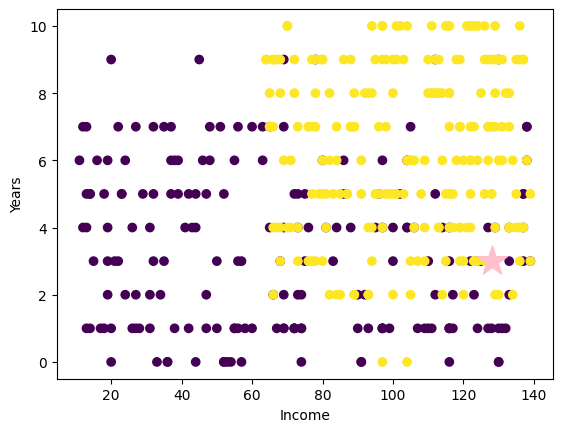

In [25]:
#Grafico al solicitante
plt.scatter(xdarray[:,2], xdarray[:,3], c=ydarray) # pongo 1 para que solo ponga la segunda columna y 2 para la tercera columna
plt.scatter(xdi[:,2], xdi[:,3], s=500,facecolor='pink', marker='*')
plt.xlabel('Income')
plt.ylabel('Years')



##Kmeans

In [26]:
from sklearn.cluster import KMeans

In [27]:
#debo tener una variable semilla para poder alojar el modleo
np.random.seed(42)

# créame 5 grupos de datos (clusters)
k= 5

#creo la variables que aloja al modelo
kMeanModel= KMeans(n_clusters=k, init='random', random_state=42)


In [28]:
# entreno el modelo
kMeanModel.fit(xdarray, ydarray)

KMeans(init='random', n_clusters=5, random_state=42)

In [29]:
# obtengo del modelo los clusters y los centroides.
labels = kMeanModel.labels_
centroids = kMeanModel.cluster_centers_
#Miro dónde está ubicado el uduario.
xdi = np.array([(21, 1,128, 3, 22, 0, 1)])
ydi=kMeanModel.predict(xdi)
print(f'El jugador evaluado pertenece al cluster {ydi[0]+1}, con indice {ydi[0]}')

El jugador evaluado pertenece al cluster 3, con indice 2


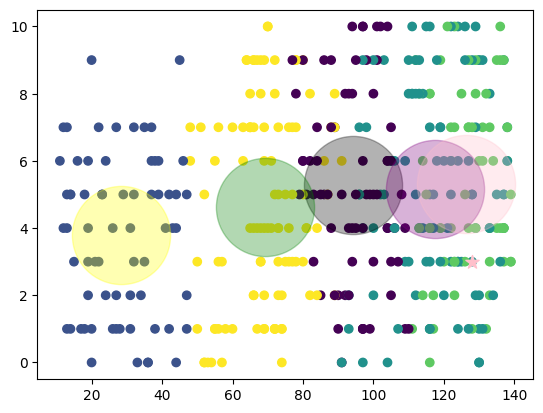

In [30]:
#grafico los clusters


plt.scatter(xdarray[:,2], xdarray[:,3], c=labels)
plt.scatter(xdi[:,2], xdi[:,3], s=100,facecolor='pink', marker='*')
colores= ['black', 'yellow', 'purple', 'pink', 'green']
plt.scatter(centroids[0,2], centroids[0,3], marker= 'o', s= 5000, facecolor=colores[0], alpha=0.3)
plt.scatter(centroids[1,2], centroids[1,3], marker= 'o', s= 5000, facecolor=colores[1], alpha=0.3)
plt.scatter(centroids[2,2], centroids[2,3], marker= 'o', s= 5000, facecolor=colores[2], alpha=0.3)
plt.scatter(centroids[3,2], centroids[3,3], marker= 'o', s= 5000, facecolor=colores[3], alpha=0.3)
plt.scatter(centroids[4,2], centroids[4,3], marker= 'o', s= 5000, facecolor=colores[4], alpha=0.3)


In [31]:
ydi= kMeanModel.predict(xdi)
print(f'El solicitante de crétdito pertenece al cluster: {ydi+1}, con índice {ydi} y con centroide de color {colores [ydi[0]]}') #pongo el +1 para que me indique el cluster, porque phyton cuenta desde 0

El solicitante de crétdito pertenece al cluster: [3], con índice [2] y con centroide de color purple


##Informes de los clusters

In [41]:
centroids

array([[ 49.92957746,   0.38028169,  94.29577465,   5.26760563,
         15.1971831 ,   0.53521127,   0.38028169],
       [ 40.41791045,   0.47761194,  28.25373134,   3.79104478,
         14.64179104,   0.52238806,   0.6119403 ],
       [ 24.97938144,   0.44329897, 117.59793814,   5.16494845,
         16.43298969,   0.53608247,   0.56701031],
       [ 51.03076923,   0.46153846, 126.15384615,   5.32307692,
         15.36923077,   0.47692308,   0.64615385],
       [ 36.69      ,   0.54      ,  69.26      ,   4.63      ,
         17.11      ,   0.57      ,   0.58      ]])

In [38]:
#Creamos una nueva columna llamada 'cluster' y asignamos los índices de los clusters a cada solicitante.
jugadores['Cluster']= labels

,Age,Sex,Income,Years,Hours,CreditCard,Facebook,Buy,Cluster
0,40,0,139,3,25,1,1,0,3
1,26,0,138,7,4,1,1,0,2
2,48,0,138,7,8,1,1,0,3
3,60,0,138,6,29,0,1,0,3
4,21,0,137,5,21,0,1,0,2
...,...,...,...,...,...,...,...,...,...
395,36,0,65,8,2,1,0,1,4
396,64,1,65,7,18,1,1,1,4
397,35,1,65,7,21,0,0,1,4
398,25,1,64,9,3,1,1,1,4


In [33]:
# hago el conteo de cuantos aprobados y cuantos prenegados hay por cluster.
counts_0 = jugadores.groupby('Cluster').agg({'Buy': lambda x:(x==0).sum()}) #así hago que me sume solamente los los valores prenegados
counts_1 = jugadores.groupby('Cluster').agg({'Buy': lambda x:(x==1).sum()}) #así hago que me sume solamente los los valores preAprobados

In [34]:
df = pd.DataFrame(np.column_stack((counts_0, counts_1)))
df.columns = ['No_compra0', 'Compra1']
df['Total'] = df.sum(axis=1, numeric_only=True)
df

,No_compra0,Compra1,Total
0,22,49,71
1,67,0,67
2,30,67,97
3,18,47,65
4,52,48,100


In [35]:
jugadores[jugadores['Cluster']==0][['Age', 'Sex', 'Income', 'Years', 'Hours', 'CreditCard', 'Facebook']].describe()

,Age,Sex,Income,Years,Hours,CreditCard,Facebook
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,49.929577,0.380282,94.295775,5.267606,15.197183,0.535211,0.380282
std,9.283355,0.488911,8.726633,2.792632,8.935674,0.502309,0.488911
min,27.000000,0.000000,77.000000,0.000000,2.000000,0.000000,0.000000
25%,43.000000,0.000000,88.000000,3.000000,6.000000,0.000000,0.000000
50%,51.000000,0.000000,95.000000,5.000000,16.000000,1.000000,0.000000
75%,56.500000,1.000000,101.000000,7.500000,23.000000,1.000000,1.000000
max,65.000000,1.000000,110.000000,10.000000,31.000000,1.000000,1.000000


In [42]:
# comparo los promedios de los que compran de los clusters
jugadores.groupby(['Cluster'])['Income'].mean().sort_values(ascending= False)

,Income
Cluster,
3,126.153846
2,117.597938
0,94.295775
4,69.260000
1,28.253731


In [37]:
# si queremos aplicar funciones a varias columnas a la vez }
jugadores.groupby(['Cluster']).agg({'Age':'mean', 'Sex':'mean', 'Years':'mean', 'CreditCard':'mean'})

,Age,Sex,Years,CreditCard
Cluster,,,,
0,49.929577,0.380282,5.267606,0.535211
1,40.417910,0.477612,3.791045,0.522388
2,24.979381,0.443299,5.164948,0.536082
3,51.030769,0.461538,5.323077,0.476923
4,36.690000,0.540000,4.630000,0.570000


#Respuestas:

##1. Descripción de las variables para el negocio:  
- Age: la edad es un factor que podría influir en la desición de compra dentro del juego.  
- Sex: Se podría ver si la intención de compra varía de acuerdo al género.  
- Income: Jugadores con mayores ingresos pueden tener un mayor interés en comprar dentro del juego.  
- Years: la cantidad de tiempo que una persona lleve jugando y conociendo el juego podría influir en la decisión de hacer o no compras dentro del mismo. Entre más tiempo, lo más probable es que compre.   
- CreditCard: tener una tarjeta de crédito puede indicar mayor facilidad para hacer compras en línea.  
- Facebook: Muchos juegos tienen respaldo con la cuenta de facebook, de pronto esto tendría que ver (si tiene la cuenta respaldad o no).  
- Buy: es la variable que demuestra el objetivo de modelo (revelar si el usuario compra o no compra).  

##2. Variable que mejor lleva a cabo el proceso de caracterización de la compra del juego.  
RTA: La variable que aparentemente tiene mayor correlación con Buy (que es aquella que estamos usando para predecir los datos) sería "Years", que tiene un 0.4970 de correlación, la más alta entre todas las variables.  

##3. Cuáles variables tienen una mayor correlación entre ellas?  
RTA: Las variables "Years" e "Income" son quienes tienen una correlación de 0.1873 que se puede observar en el heatmap más claramente. No es una correlación muy alta pero es la más alta entre todas las demás variables.  

##4. Exactitud, sensibilidad y especificidad.  
RTA:
- Exactitud: la proporción de predicciones correctas sobre el total es de 76.50%. No es un mal valor pero podría ser más alto.  
- Sensibilidad: El modelo clasificó bien el 84.36% de usuarios que realizan/pueden realizar compras en el juego. Esto indica que los valores de falsos negativos en realidad no es demasiado alto.  
- Especificidad: el 67.72% de los usuarios que NO hacen compras dentro del juego fueron clasificados correctamente por el modelo.  

##5. Usuario con características [(21,    1,    128,    3,    22,    0,    1)] compra o no compra?  

RTA: De acuerdo como se ve en el notebook, la predicción para este usuario es de 0, es decir, no haría la compra.  

##6. ubicación del inidviduo en la gráfica KNN y Kmeans usando Income vs Years  
RTA: Este procedimiento y las gráficas se pueden ver más arriba en el notebook.  

##7. Número de individuos que va a comprar a través de la app según cluster.  
RTA:  
- Cluster 1 (índice 0) = 49  
- Cluster 2 (índice 1) = 0  
- Cluster 3 (índice 2) = 67  
- Cluster 4 (índice 3) = 47  
- Cluster 5 (índice 4) = 48  
El cluster con mayor compradores es el cluster 3 con índice 2.  

##8. Clústeres.

- promedio de más jóvenes: Cluster 3 con índice 2. (24.97)    
- promedio de de más mujeres: Cluster 1 con índice 0.** (0.38)
- promedio de más años de juego: Cluster 4 con índice 3. (5.32)
- promedio de más tarjetas de crédito: Cluster 5 con índice 4. (0.57)
